In [12]:
#!/usr/bin/env python
# coding: utf-8

# In[ ]:


# Loss-landscape mockup for Gradient Consistency
# Works in a Jupyter notebook. Produces:
#  - Matplotlib 3D surfaces (static, publication-friendly)
#  - Optional Plotly interactive 3D surfaces (nice for exploring camera angles)
#
# Surface definition (per your paper):
# ΔL̃(u1, dL/du2; dL/dS) = (dL/dS) * ΔS(u1) + (dL/du2) * Δu2(u1)
# where:
#   ΔS = +1 if u1 < Vth else -1
#   Δu2 = -u1 if u1 < Vth else Vth

import numpy as np

In [13]:
# -----------------------------
# Core surface definition
# -----------------------------
def deltaS(u1, Vth=1.0):
    return np.where(u1 < Vth, 1.0, -1.0)

def delta_u2(u1, Vth=1.0):
    return np.where(u1 < Vth, -u1, Vth)

def delta_L_tilde(U1, dL_du2, dL_dS=1.0, Vth=1.0):
    """
    Vectorized. U1 and dL_du2 can be scalars or arrays broadcastable to same shape.
    """
    return dL_dS * deltaS(U1, Vth) + dL_du2 * delta_u2(U1, Vth)

In [ ]:
# -----------------------------
# Surrogate Gradient Functions
# -----------------------------
def get_dS_du1(u, thresh=1.0, gama=1.0, mode='Gamma', alpha=4.0):
    if mode == "sigmoid":
        sgax = (u - thresh) * alpha
        # sigmoid(x) = 1 / (1 + exp(-x))
        sig = 1.0 / (1.0 + np.exp(-sgax))
        return (1.0 - sig) * sig * alpha
    elif mode == "Gamma":
        # Standard triangular surrogate
        return (1.0 / gama**2) * np.maximum(0, gama - np.abs(u - thresh))

    # Default fallback
    return (1.0 / gama**2) * np.maximum(0, gama - np.abs(u - thresh))

def standard_gradient(u1, dL_dS, dL_du2, thresh=1.0, gama=1.0, mode='Gamma', alpha=4.0, detach_reset=True):
    dS_du1 = get_dS_du1(u1, thresh, gama, mode, alpha)
    spike = (u1 >= thresh).astype(float)

    if detach_reset:
        # Reset gradient is just (1 - S)
        du2_du1 = (1.0 - spike)
    else:
        # Full gradient: (1 - S) - U * dS/dU
        du2_du1 = (1.0 - spike) - u1 * dS_du1

    return dL_dS * dS_du1 + dL_du2 * du2_du1

In [14]:
def check_alignment(u1, dL_dS, dL_du2, thresh=1.0, gama=1.0, mode='Gamma', alpha=4.0, detach_reset=True, only_towards_thresh=True):
    """
    Returns 1 if aligned, -1 if misaligned, 0 if no gradient or no loss change.
    Alignment: sign(dL/du1) = -sign(Delta L tilde)
    
    If only_towards_thresh=True, then misalignment is only flagged if the gradient 
    would cause an update -dL/du1 that points toward the threshold.
    """
    Z = delta_L_tilde(u1, dL_du2, dL_dS=dL_dS, Vth=thresh)
    g = standard_gradient(u1, dL_dS, dL_du2, thresh, gama, mode, alpha, detach_reset)

    # We use a small epsilon to avoid noise around 0
    eps = 1e-9
    alignment = -np.sign(g) * np.sign(Z)
    
    if only_towards_thresh:
        # Update is du1 = -eta * g. 
        # Points towards threshold if:
        # u1 < thresh AND g < 0  => sign(u1 - thresh) = -1 AND sign(g) = -1
        # u1 > thresh AND g > 0  => sign(u1 - thresh) = 1 AND sign(g) = 1
        # So points towards if sign(g) == sign(u1 - thresh) is FALSE? No.
        # Let's re-verify:
        # If u1 = 0.8, thresh = 1.0. u1 - thresh = -0.2. sign = -1. 
        # We want du = -g to be positive, so g < 0. sign(g) = -1.
        # If u1 = 1.2, thresh = 1.0. u1 - thresh = 0.2. sign = 1.
        # We want du = -g to be negative, so g > 0. sign(g) = 1.
        # So points towards if sign(g) == sign(u1 - thresh).
        
        towards = (np.sign(g) == np.sign(u1 - thresh))
        
        # We only care about filtering the MISALIGNED cases (alignment == -1)
        # If it's misaligned but points AWAY from threshold, we set alignment to 0.
        alignment[(alignment == -1) & (~towards)] = 0

    alignment[np.abs(g) < eps] = 0
    alignment[np.abs(Z) < eps] = 0
    return alignment

In [15]:
# -----------------------------
# Grid helpers
# -----------------------------
def make_grid(
    u1_min=0.0, u1_max=2.0, u1_n=250,
    dLdu2_min=-2.0, dLdu2_max=2.0, dLdu2_n=250
):
    u1 = np.linspace(u1_min, u1_max, u1_n)
    dLdu2 = np.linspace(dLdu2_min, dLdu2_max, dLdu2_n)
    U1, D = np.meshgrid(u1, dLdu2, indexing="xy")
    return U1, D

In [16]:
# -----------------------------
# Matplotlib (static)
# -----------------------------
def plot_matplotlib_surfaces(
    dL_dS_values=(-1.0, 0.0, 1.0),
    Vth=1.0,
    u1_range=(0.0, 2.0),
    dLdu2_range=(-2.0, 2.0),
    grid_n=500,
    z_clip=None,  # e.g. (-4, 4) to clip z-range for readability
    elev=25,
    azim=-60,
    add_threshold_plane=True,
    show_alignment=False,
    show_gradient=False,
    surrogate_mode='Gamma',
    gama=1.0,
    alpha=4.0,
    detach_reset=True,
    only_towards_thresh=True,
):
    import matplotlib.pyplot as plt
    from matplotlib.colors import TwoSlopeNorm

    U1, D = make_grid(
        u1_min=u1_range[0], u1_max=u1_range[1], u1_n=grid_n,
        dLdu2_min=dLdu2_range[0], dLdu2_max=dLdu2_range[1], dLdu2_n=grid_n
    )

    n = len(dL_dS_values)
    num_extra = (1 if show_alignment else 0) + (1 if show_gradient else 0)
    rows = 1 + num_extra
    fig = plt.figure(figsize=(6.5 * n, 5.5 * rows))

    # Common normalization: center at 0 to emphasize consistent vs inconsistent sign
    # (ΔL̃ < 0 consistent; ΔL̃ > 0 inconsistent)
    # We'll compute per-panel z-lims unless z_clip is set.
    for i, dL_dS in enumerate(dL_dS_values, start=1):
        # --- Row 1: Delta L Tilde ---
        ax = fig.add_subplot(rows, n, i, projection="3d")

        Z = delta_L_tilde(U1, D, dL_dS=dL_dS, Vth=Vth)

        if z_clip is not None:
            Z_plot = np.clip(Z, z_clip[0], z_clip[1])
            zmin, zmax = z_clip
        else:
            Z_plot = Z
            zmin, zmax = np.min(Z_plot), np.max(Z_plot)

        # Diverging colormap centered at 0
        norm = TwoSlopeNorm(vmin=zmin, vcenter=0.0, vmax=zmax)

        surf = ax.plot_surface(
            U1, D, Z_plot,
            rstride=2, cstride=2,
            linewidth=0, antialiased=True,
            norm=norm,
            cmap="RdBu_r"  # Diverging colormap: Blue for negative (consistent), Red for positive (inconsistent)
        )

        ax.set_title(rf"$\partial L/\partial S = {dL_dS:g}$", pad=12)
        ax.set_xlabel(r"$u_1$")
        ax.set_ylabel(r"$\partial L/\partial u_2$")
        ax.set_zlabel(r"$\Delta 	ilde{L}$")

        ax.view_init(elev=elev, azim=azim)

        # Optional: show the threshold plane u1 = Vth as a vertical translucent sheet
        if add_threshold_plane:
            # Build a thin plane at u1=Vth spanning y-range and z-range
            yy = np.linspace(dLdu2_range[0], dLdu2_range[1], 50)
            zz = np.linspace(zmin, zmax, 50)
            YY, ZZ = np.meshgrid(yy, zz, indexing="xy")
            XX = np.full_like(YY, Vth)
            ax.plot_surface(XX, YY, ZZ, alpha=0.15, linewidth=0)

        # Mark consistency boundary ΔL̃=0 via contour on the surface
        try:
            ax.contour(
                U1, D, Z,
                levels=[0.0],
                colors='black',
                linewidths=2,
                linestyles='dashed'
            )
            # Also project to bottom
            ax.contour(
                U1, D, Z,
                levels=[0.0],
                offset=zmin,
                colors='black',
                linewidths=1,
                alpha=0.5
            )
        except Exception:
            pass

        # Add a colorbar per axis
        cbar = fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.08, aspect=18)
        cbar.set_label(r"$\Delta 	ilde{L}$ (<0: Consistent, >0: Inconsistent)")

        # Aesthetics
        ax.set_xlim(u1_range)
        ax.set_ylim(dLdu2_range)
        ax.set_zlim((zmin, zmax))

        # --- Optional: Gradient (Row 2 if enabled) ---
        current_row_idx = 0
        if show_gradient:
            current_row_idx += 1
            ax_grad = fig.add_subplot(rows, n, i + current_row_idx * n, projection="3d")
            
            K = standard_gradient(U1, dL_dS, D, thresh=Vth, gama=gama, mode=surrogate_mode, alpha=alpha, detach_reset=detach_reset)
            
            # Use symmetric bounds for gradient so 0 is centered
            m_grad = np.max(np.abs(K)) if np.max(np.abs(K)) > 0 else 1.0
            norm_grad = TwoSlopeNorm(vmin=-m_grad, vcenter=0.0, vmax=m_grad)
            
            surf_grad = ax_grad.plot_surface(
                U1, D, K,
                rstride=2, cstride=2,
                linewidth=0, antialiased=True,
                norm=norm_grad,
                cmap="PuOr" # Purple-Orange diverging
            )
            
            ax_grad.set_title(rf"$\partial L/\partial u_1$ (dL/du1)", pad=12)
            ax_grad.set_xlabel(r"$u_1$")
            ax_grad.set_ylabel(r"$\partial L/\partial u_2$")
            ax_grad.set_zlabel(r"$\partial L/\partial u_1$")
            ax_grad.view_init(elev=elev, azim=azim)
            
            if add_threshold_plane:
                yy = np.linspace(dLdu2_range[0], dLdu2_range[1], 50)
                zz = np.linspace(-m_grad, m_grad, 50)
                YY, ZZ = np.meshgrid(yy, zz, indexing="xy")
                XX = np.full_like(YY, Vth)
                ax_grad.plot_surface(XX, YY, ZZ, alpha=0.1, color='black')
                
            fig.colorbar(surf_grad, ax=ax_grad, shrink=0.6, pad=0.08, aspect=18)

        # --- Optional: Alignment ---
        if show_alignment:
            current_row_idx += 1
            ax2 = fig.add_subplot(rows, n, i + current_row_idx * n, projection="3d")
            
            A = check_alignment(U1, dL_dS, D, thresh=Vth, gama=gama, mode=surrogate_mode, alpha=alpha, detach_reset=detach_reset, only_towards_thresh=only_towards_thresh)
            
            # Colormap for alignment: Green for Aligned (1), Red for Misaligned (-1), Gray for Neutral (0)
            from matplotlib.colors import ListedColormap
            align_cmap = ListedColormap(['#ff4c4c', '#cccccc', '#4cff4c']) # Red, Gray, Green
            norm_align = plt.Normalize(vmin=-1, vmax=1)
            
            surf2 = ax2.plot_surface(
                U1, D, A,
                rstride=2, cstride=2,
                linewidth=0, antialiased=True,
                cmap=align_cmap,
                norm=norm_align,
                alpha=0.8
            )
            
            ax2.set_title(rf"Alignment ($\partial L/\partial u_1$ vs $\Delta 	ilde{{L}}$)", pad=12)
            ax2.set_xlabel(r"$u_1$")
            ax2.set_ylabel(r"$\partial L/\partial u_2$")
            ax2.set_zlabel("Alignment")
            ax2.set_zlim(-1.1, 1.1)
            ax2.view_init(elev=elev, azim=azim)
            
            if add_threshold_plane:
                XX = np.full((50, 50), Vth)
                YY, ZZ = np.meshgrid(np.linspace(dLdu2_range[0], dLdu2_range[1], 50), np.linspace(-1, 1, 50))
                ax2.plot_surface(XX, YY, ZZ, alpha=0.1, color='black')

    plt.tight_layout()
    plt.show()

In [17]:
# -----------------------------
# Plotly (interactive)
# -----------------------------
def plot_plotly_surfaces(
    dL_dS_values=(-1.0, 0.0, 1.0),
    Vth=1.0,
    u1_range=(0.0, 2.0),
    dLdu2_range=(-2.0, 2.0),
    grid_n=200,
    z_clip=None,
    add_threshold_plane=True,
    show_alignment=False,
    show_gradient=False,
    surrogate_mode='Gamma',
    gama=1.0,
    alpha=4.0,
    detach_reset=True,
    only_towards_thresh=True,
):
    """
    Requires: pip install plotly
    In Jupyter, this will render interactively (rotate/zoom).
    """
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots

    U1, D = make_grid(
        u1_min=u1_range[0], u1_max=u1_range[1], u1_n=grid_n,
        dLdu2_min=dLdu2_range[0], dLdu2_max=dLdu2_range[1], dLdu2_n=grid_n
    )

    n = len(dL_dS_values)
    num_extra = (1 if show_alignment else 0) + (1 if show_gradient else 0)
    rows = 1 + num_extra
    
    subplot_titles = [rf"dL/dS = {v:g}" for v in dL_dS_values]
    if show_gradient:
        subplot_titles += [rf"dL/du1 (dL/dS={v:g})" for v in dL_dS_values]
    if show_alignment:
        subplot_titles += [rf"Alignment (dL/dS={v:g})" for v in dL_dS_values]

    fig = make_subplots(
        rows=rows, cols=n,
        specs=[[{"type": "surface"}] * n] * rows,
        subplot_titles=subplot_titles,
        horizontal_spacing=0.03,
        vertical_spacing=0.08
    )

    # We'll use a diverging colorscale centered around zero in display logic
    # by setting zmin/zmax symmetric if not clipped.
    for j, dL_dS in enumerate(dL_dS_values, start=1):
        Z = delta_L_tilde(U1, D, dL_dS=dL_dS, Vth=Vth)

        if z_clip is not None:
            Zp = np.clip(Z, z_clip[0], z_clip[1])
            zmin_L, zmax_L = z_clip
        else:
            # Symmetric bounds around 0 so sign is visually stable across panels
            m = np.max(np.abs(Z))
            zmin_L, zmax_L = -m, m
            Zp = Z

        fig.add_trace(
            go.Surface(
                x=U1, y=D, z=Zp,
                cmin=zmin_L, cmax=zmax_L,
                showscale=(j == n),  # one colorbar on the last panel
                opacity=1.0,
                colorscale='RdBu',
                reversescale=True, # Blue for negative, Red for positive
                contours=dict(z=dict(show=True, start=0, end=0, size=1, color='black', width=4))
            ),
            row=1, col=j
        )

        if add_threshold_plane:
            # Threshold plane at x=Vth with low opacity
            yy = np.linspace(dLdu2_range[0], dLdu2_range[1], 60)
            zz = np.linspace(zmin_L, zmax_L, 60)
            YY, ZZ = np.meshgrid(yy, zz, indexing="xy")
            XX = np.full_like(YY, Vth)

            fig.add_trace(
                go.Surface(
                    x=XX, y=YY, z=ZZ,
                    opacity=0.15,
                    showscale=False
                ),
                row=1, col=j
            )

        curr_row = 1
        if show_gradient:
            curr_row += 1
            K = standard_gradient(U1, dL_dS, D, thresh=Vth, gama=gama, mode=surrogate_mode, alpha=alpha, detach_reset=detach_reset)
            m_k = np.max(np.abs(K)) if np.max(np.abs(K)) > 0 else 1.0
            
            fig.add_trace(
                go.Surface(
                    x=U1, y=D, z=K,
                    colorscale='PuOr',
                    cmin=-m_k, cmax=m_k,
                    showscale=False,
                    opacity=0.8
                ),
                row=curr_row, col=j
            )
            
            if add_threshold_plane:
                yy = np.linspace(dLdu2_range[0], dLdu2_range[1], 30)
                zz = np.linspace(-m_k, m_k, 30)
                YY, ZZ = np.meshgrid(yy, zz, indexing="xy")
                XX = np.full_like(YY, Vth)
                fig.add_trace(
                    go.Surface(x=XX, y=YY, z=ZZ, opacity=0.1, showscale=False),
                    row=curr_row, col=j
                )

        if show_alignment:
            curr_row += 1
            A = check_alignment(U1, dL_dS, D, thresh=Vth, gama=gama, mode=surrogate_mode, alpha=alpha, detach_reset=detach_reset, only_towards_thresh=only_towards_thresh)
            
            fig.add_trace(
                go.Surface(
                    x=U1, y=D, z=A,
                    colorscale=[[0, '#ff4c4c'], [0.5, '#cccccc'], [1, '#4cff4c']],
                    cmin=-1, cmax=1,
                    showscale=False,
                    opacity=0.8
                ),
                row=curr_row, col=j
            )
            
            if add_threshold_plane:
                yy = np.linspace(dLdu2_range[0], dLdu2_range[1], 30)
                zz = np.linspace(-1, 1, 30)
                YY, ZZ = np.meshgrid(yy, zz, indexing="xy")
                XX = np.full_like(YY, Vth)
                fig.add_trace(
                    go.Surface(x=XX, y=YY, z=ZZ, opacity=0.1, showscale=False),
                    row=curr_row, col=j
                )

    # Layout styling
    for r in range(1, rows + 1):
        for c in range(1, n + 1):
            idx = (r - 1) * n + c
            scene_name = "scene" if idx == 1 else f"scene{idx}"
            
            # Determine titles and ranges based on actual rows
            if r == 1:
                z_title = "ΔL~"
                z_range = [zmin_L, zmax_L]
            elif (r == 2 and show_gradient) or (r == 3 and show_gradient and show_alignment):
                if r == 2 and show_gradient:
                    z_title = "dL/du1"
                    # We'd need to store per-panel m_k if we wanted exact bounds, 
                    # but letting plotly auto-scale per scene or using a global max is easier.
                    z_range = None 
                else: # this must be alignment at row 3
                    z_title = "Alignment"
                    z_range = [-1.1, 1.1]
            else: # Row 2 alignment if no gradient
                z_title = "Alignment"
                z_range = [-1.1, 1.1]
            
            fig.update_layout(**{
                scene_name: dict(
                    xaxis_title="u1",
                    yaxis_title="dL/du2",
                    zaxis_title=z_title,
                    xaxis=dict(range=list(u1_range)),
                    yaxis=dict(range=list(dLdu2_range)),
                    zaxis=dict(range=z_range) if z_range else dict(),
                )
            })

    fig.update_layout(
        title="Effective jump-induced loss change and gradient surfaces",
        height=500 * rows,
        width=520 * n,
        margin=dict(l=0, r=0, t=45, b=0),
    )
    fig.show()

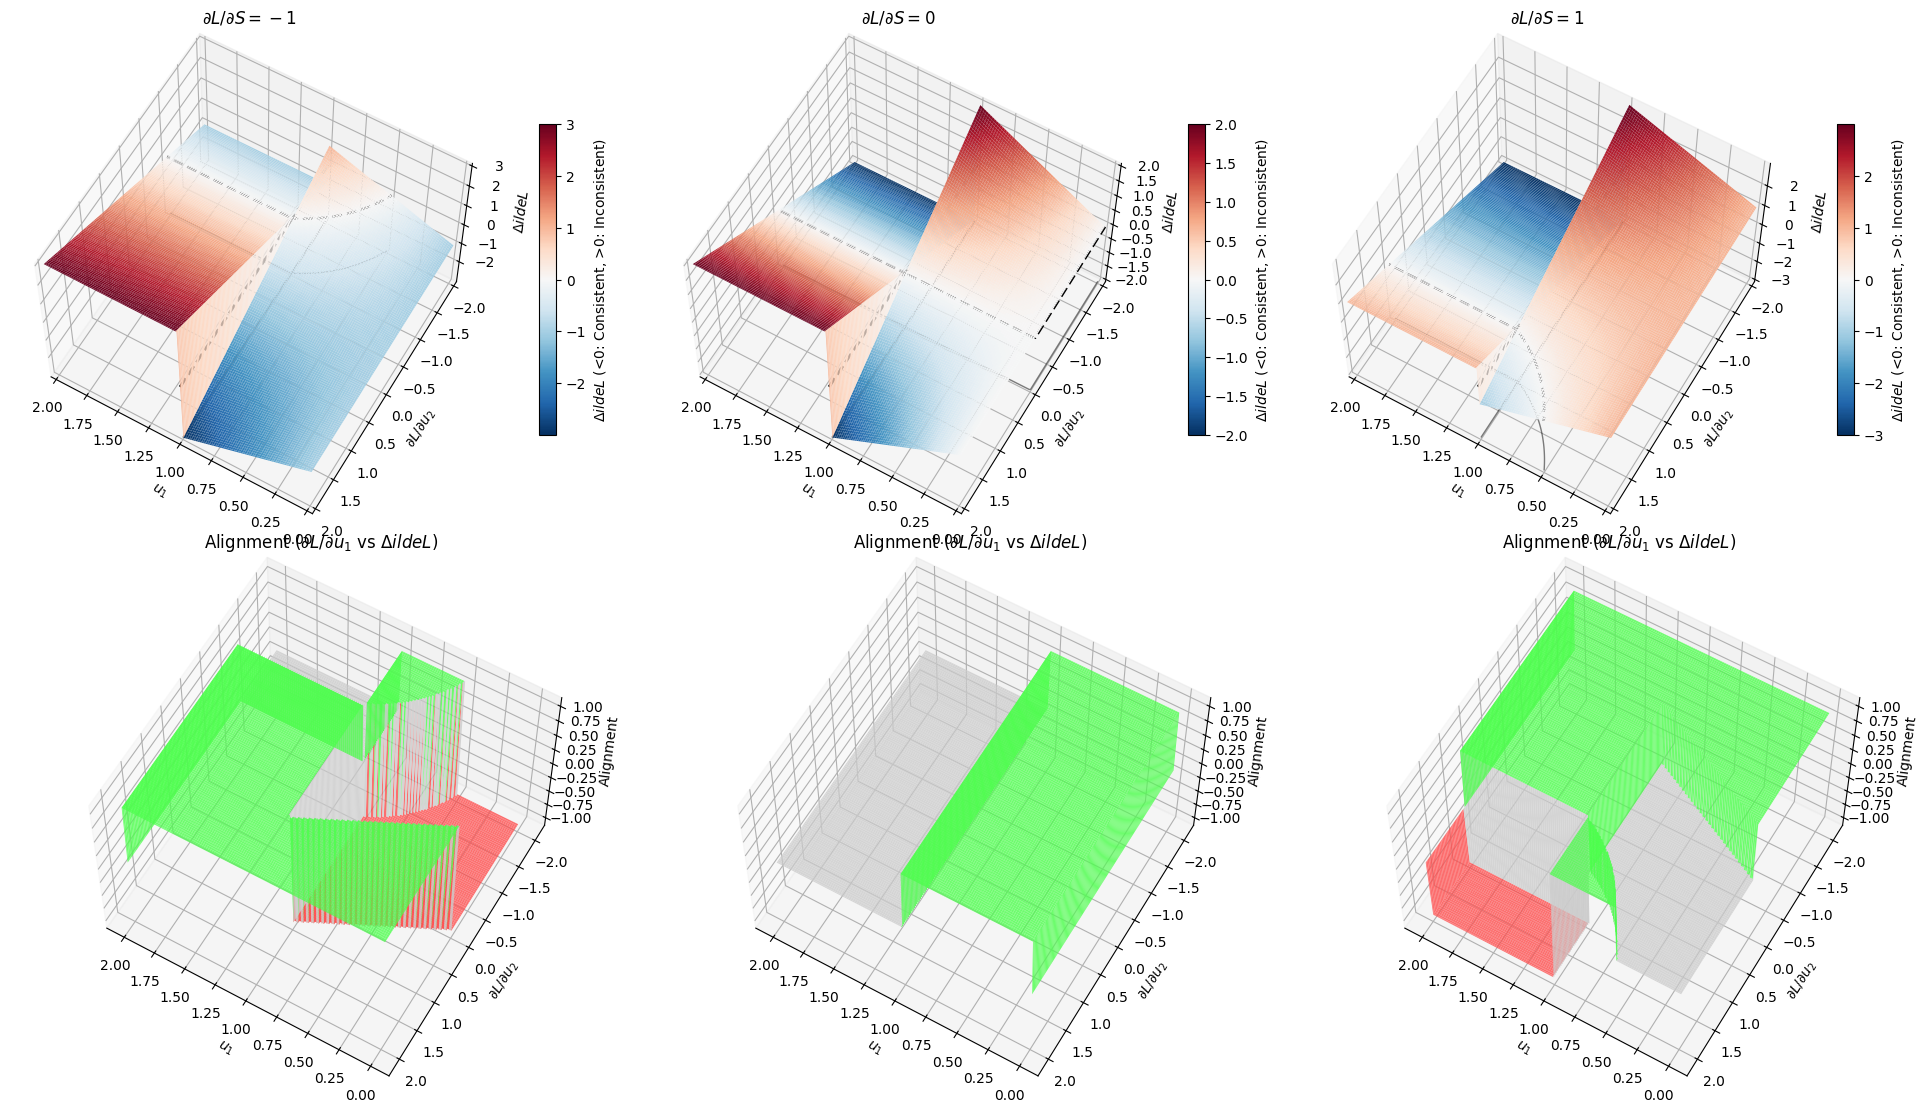

In [18]:
# -----------------------------
# Example usage
# -----------------------------
# 1) Matplotlib: good for paper figures
plot_matplotlib_surfaces(
    dL_dS_values=(-1.0, 0.0, 1.0),
    Vth=1.0,
    u1_range=(0.0, 2.0),
    dLdu2_range=(-2.0, 2.0),
    grid_n=250,
    z_clip=None,         # try (-4, 4) if you want clipping
    elev=60,
    azim=120,
    add_threshold_plane=False,
    show_alignment=True,  # <--- New option
    surrogate_mode='Gamma',
    gama=1.0,
    detach_reset=True
)

# 2) Plotly: interactive exploration (uncomment if you have plotly installed)
# plot_plotly_surfaces(
#     dL_dS_values=(-1.0, 0.0, 1.0),
#     Vth=1.0,
#     u1_range=(0.0, 2.0),
#     dLdu2_range=(-2.0, 2.0),
#     grid_n=200,
#     z_clip=None,
#     add_threshold_plane=True
# )



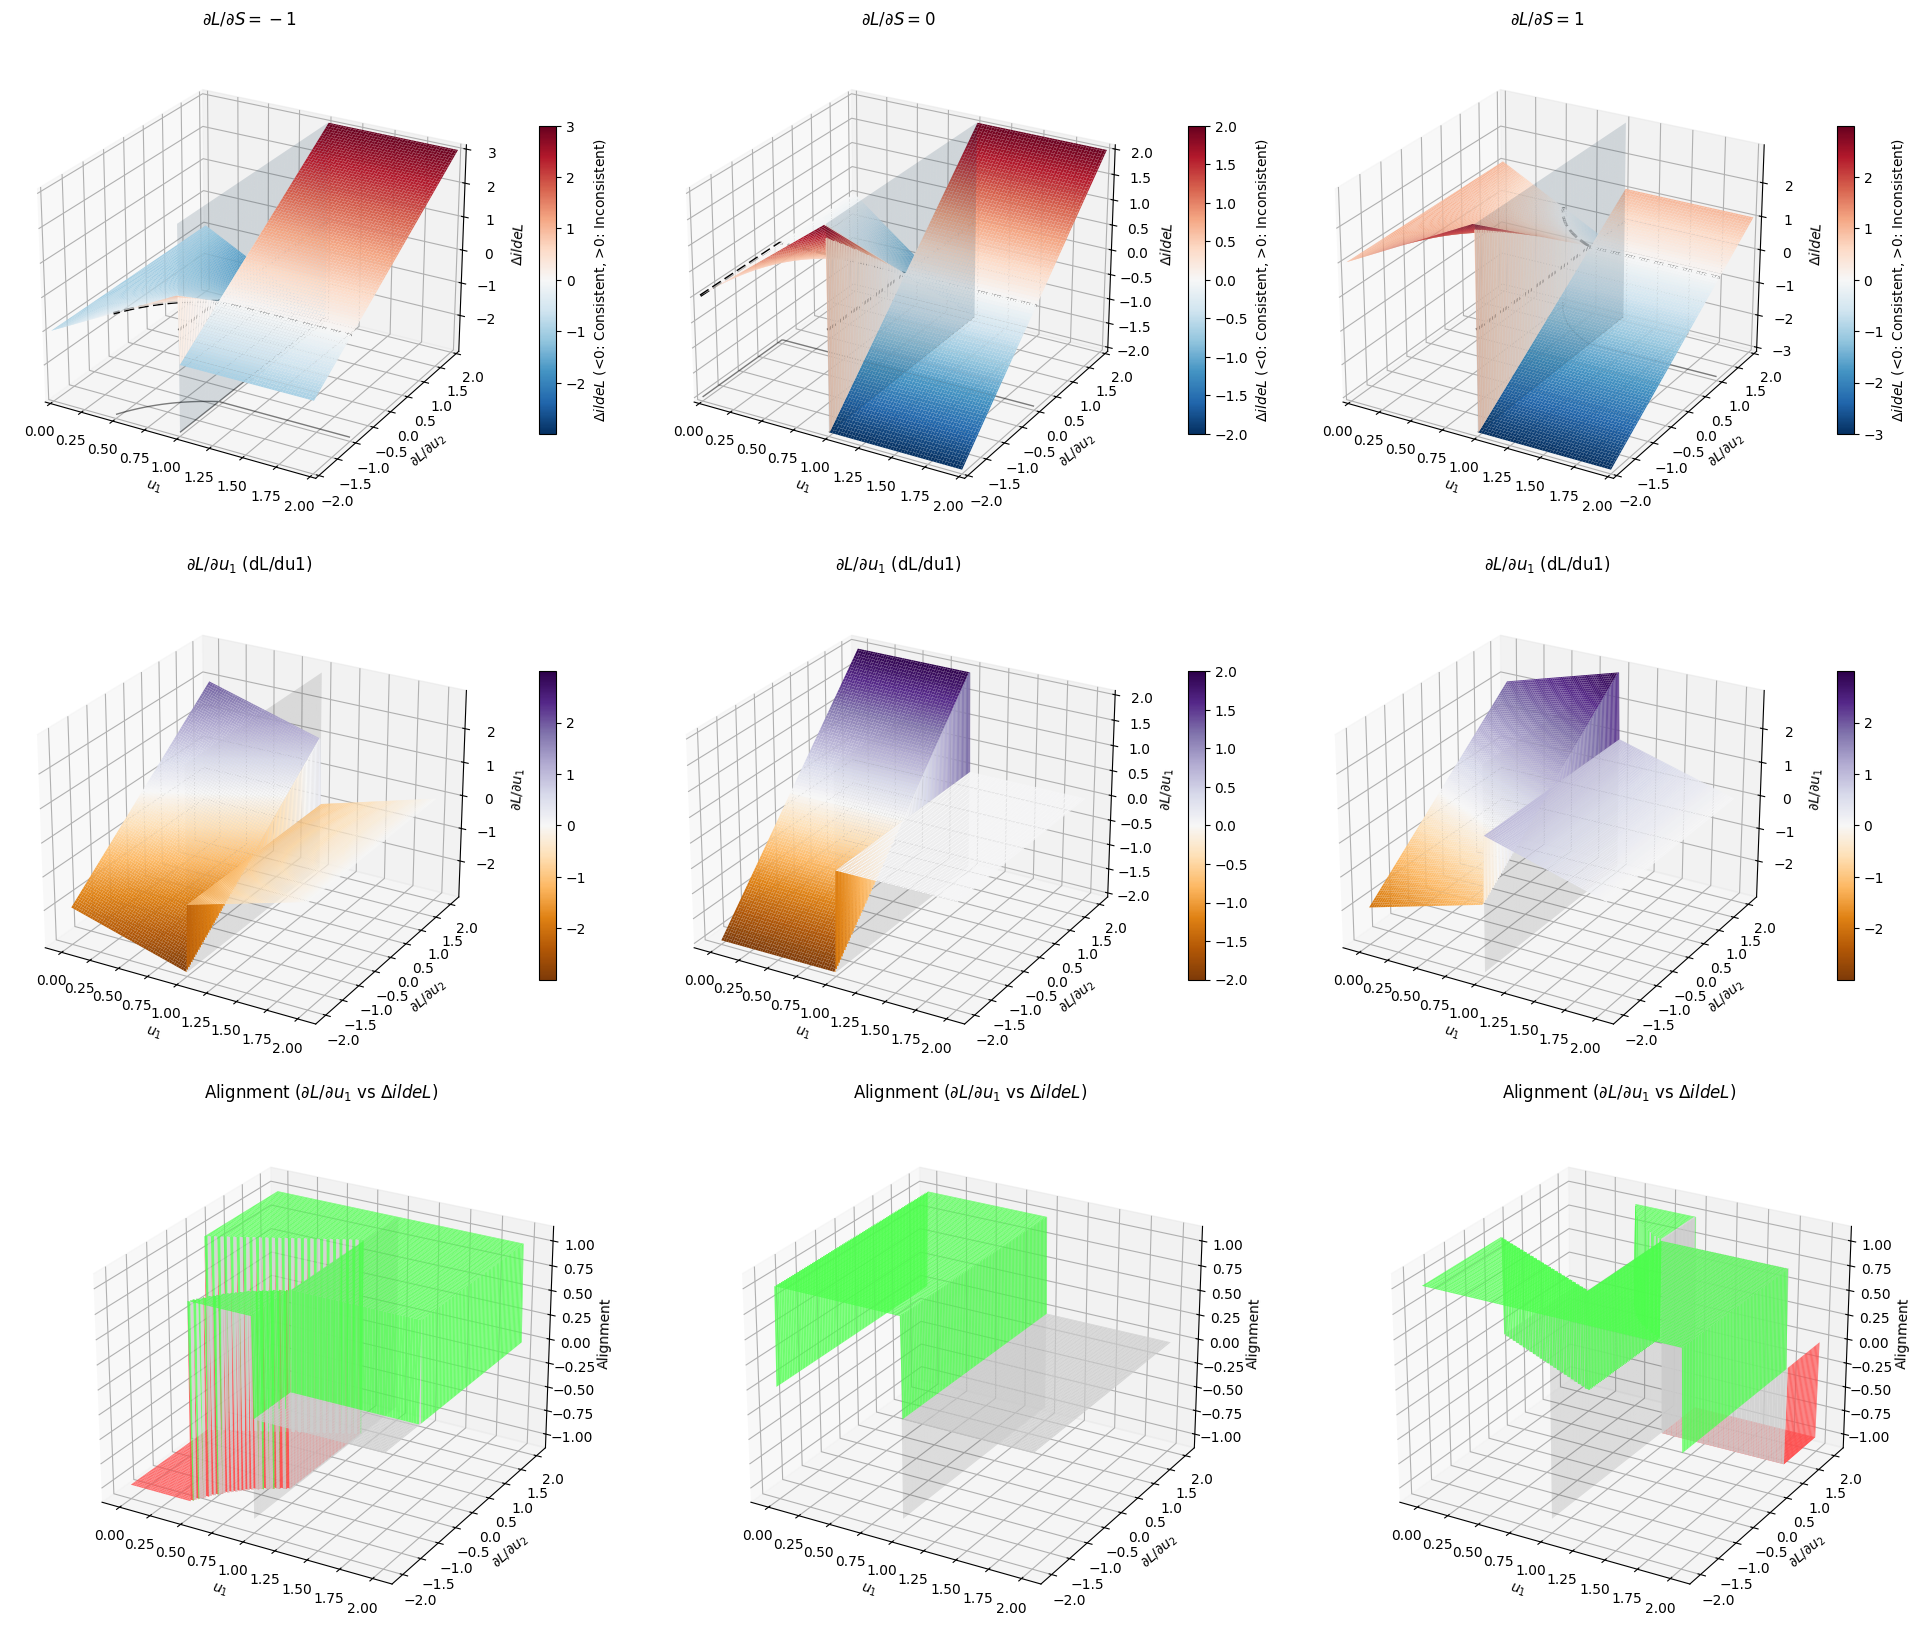

ModuleNotFoundError: No module named 'plotly'

In [ ]:
# -----------------------------
# Visualization with dL/du1
# -----------------------------
# New graphs showing dL/du1 (surrogate gradient) have been added.
# You can enable them by setting show_gradient=True.

plot_matplotlib_surfaces(
    dL_dS_values=(-1.0, 0.0, 1.0),
    show_gradient=True,
    show_alignment=True,
    grid_n=200,
    elev=60
)

# Interactive Plotly visualization
plot_plotly_surfaces(
    dL_dS_values=(-1.0, 0.0, 1.0),
    show_gradient=True,
    show_alignment=True,
    grid_n=100
)